<a href="https://colab.research.google.com/github/htcmrl/SesTanima/blob/main/SesTanima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import librosa
from google.colab import drive

# 1. Google Drive'ı sisteme bağla
drive.mount('/content/drive')

# 2. Ses dosyasının yolu
dosya_yolu = '/content/drive/MyDrive/Sesler/common_voice_tr_17341269.mp3'

# 3. Sesi sayısal verilere dönüştür
ses_matrisi, ornekleme_hizi = librosa.load(dosya_yolu)

print(" Ses verisi başarıyla işleme alındı.")
print(f"Frekans: {ornekleme_hizi} Hz | Veri Boyutu: {len(ses_matrisi)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Ses verisi başarıyla işleme alındı.
Frekans: 22050 Hz | Veri Boyutu: 106899


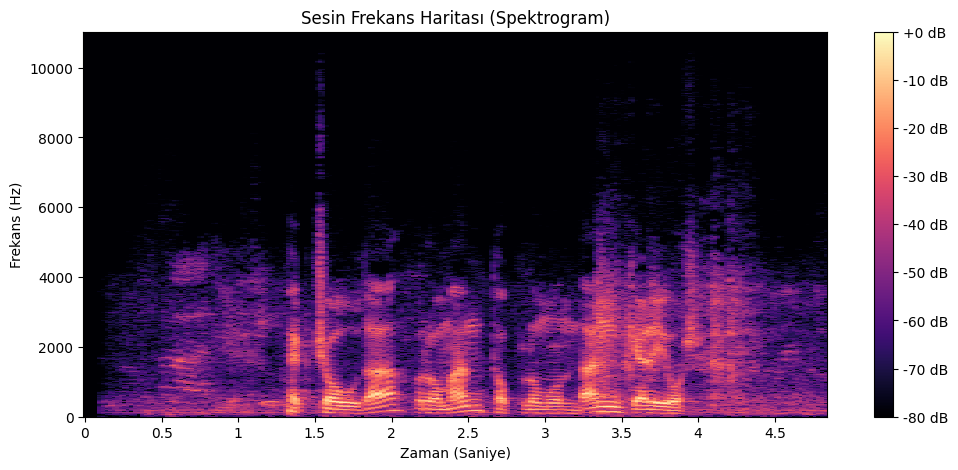

In [ ]:
# Kaggle'da Bulduğun "STFT" İşlemi
# Bilgisayar bu ses_matrisi içindeki sayıları hala "anlamlı bir konuşma" olarak göremiyor.
# Bunu modelin (Yapay Zekanın) anlayabileceği bir "Frekans Haritasına" (Spektrogram) dönüştürmemiz lazım.

import matplotlib.pyplot as plt
import librosa.display
import numpy as np

# 1. STFT (Kısa Zamanlı Fourier Dönüşümü) ile sesi frekanslara ayır
stft_sonucu = librosa.stft(ses_matrisi)

# 2. İnsan kulağının algısına (Desibel) dönüştür
desibel_haritası = librosa.amplitude_to_db(np.abs(stft_sonucu), ref=np.max)

# 3. Spektrogram grafiğini çizdir
plt.figure(figsize=(12, 5))
librosa.display.specshow(desibel_haritası, sr=ornekleme_hizi, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Sesin Frekans Haritası (Spektrogram)')
plt.xlabel('Zaman (Saniye)')
plt.ylabel('Frekans (Hz)')
plt.show()

In [ ]:
import librosa
import torch
from transformers import WhisperProcessor, WhisperForConditionalGeneration

# 1. Pipeline YERİNE, İşlemciyi ve Modeli doğrudan indiriyoruz
print(" İşlemci ve Model yükleniyor...")
processor = WhisperProcessor.from_pretrained("openai/whisper-tiny")
model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-tiny")

# 2. Sesi 16000 Hz'de doğrudan matrise çevir
dosya_yolu = '/content/drive/MyDrive/Sesler/common_voice_tr_17341269.mp3'
ses_matrisi_16k, ornekleme_hizi = librosa.load(dosya_yolu, sr=16000)

# 3. Matrisi modelin anlayacağı "Tensör" formatına dönüştür
print("Sesi işliyor...")
girdiler = processor(ses_matrisi_16k, sampling_rate=16000, return_tensors="pt")

# 4. Yapay zekaya zorla TÜRKÇE olduğunu belirtiyoruz
print("Metin oluşturuluyor...")
uretilen_idler = model.generate(
    girdiler.input_features,
    language="turkish",    # DİLİ SABİTLEDİK
    task="transcribe"      # SADECE YAZIYA ÇEVİR DEDİK
)
sonuc_metni = processor.batch_decode(uretilen_idler, skip_special_tokens=True)[0]

print("-" * 50)
print(" Çıktı:", sonuc_metni)
print("-" * 50)

 İşlemci ve Model yükleniyor...


Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

Sesi işliyor...
Metin oluşturuluyor...
--------------------------------------------------
 Çıktı:  pek çoğuda romantoplu mundan geliyor.
--------------------------------------------------


In [ ]:
# 1. Hata ölçüm kütüphanesini kuruyoruz (Sadece bir kez çalıştır)
!pip install -q jiwer

from jiwer import wer

# 2. Gerçek metin (Veri setinden gelen doğru hali)
gercek_metin = "pek çoğu da roman toplumundan geliyor"

# 3. Senin çalıştırdığın modelin bulduğu metin
model_tahmini = "pek çoğuda romantoplu mundan geliyor"

# 4. WER (Kelime Hata Oranı) Hesaplama
hata_skoru = wer(gercek_metin, model_tahmini)

# 5. Sonuçları profesyonelce yazdır
print("=" * 50)
print(f" Gerçek Metin:  {gercek_metin}")
print(f" Model Çıktısı: {model_tahmini}")
print("-" * 50)
print(f" Modelin Hata Oranı (WER): %{hata_skoru * 100:.2f}")
print("=" * 50)

 Gerçek Metin:  pek çoğu da roman toplumundan geliyor
 Model Çıktısı: pek çoğuda romantoplu mundan geliyor
--------------------------------------------------
 Modelin Hata Oranı (WER): %66.67


In [ ]:
!pip install -q speechbrain torchaudio transformers librosa

import os
import torch
import torchaudio
import librosa
import torch.nn.functional as F
from speechbrain.inference.speaker import EncoderClassifier
from transformers import WhisperProcessor, WhisperForConditionalGeneration

print(" SİSTEM BAŞLATILIYOR...")

# ---------------- 1. MODELLERİ YÜKLEME ----------------
print("1. Ses Tanıma ve Metin Çeviri Modelleri Yükleniyor (Bu biraz sürebilir)...")
# Ses Kimliği Modeli (SpeechBrain)
device = "cuda" if torch.cuda.is_available() else "cpu"
kimlik_modeli = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb",
    savedir="pretrained_models/spkrec-ecapa-voxceleb",
    run_opts={"device": device}
)

# Metin Çeviri Modeli (Whisper - Hata vermeyen özel yapımız)
whisper_islemci = WhisperProcessor.from_pretrained("openai/whisper-tiny")
whisper_modeli = WhisperForConditionalGeneration.from_pretrained("openai/whisper-tiny")

# ---------------- 2. TEST EDİLECEK SES ----------------
# Veritabanı klasörümüz
db_klasoru = "/content/drive/MyDrive/Ses_Sifreleri_DB"

# Buraya test etmek istediğin herhangi bir ses dosyasının yolunu koy!
# (Örneğin Mozilla'dan indirdiğin bir ses veya kendi kaydettiğin yeni bir ses)
test_sesi_yolu = "/content/drive/MyDrive/Sesler/common_voice_tr_41208388.mp3"

print(f"\n🎧 {test_sesi_yolu} dosyası analiz ediliyor...")

# ---------------- 3. AŞAMA: KİM KONUŞUYOR? ----------------
# Sesi SpeechBrain için hazırla
sinyal, ornekleme_hizi = torchaudio.load(test_sesi_yolu)
if ornekleme_hizi != 16000:
    sinyal = torchaudio.transforms.Resample(orig_freq=ornekleme_hizi, new_freq=16000)(sinyal)

# Test sesinin şifresini (vektörünü) çıkar
with torch.no_grad():
    test_vektoru = kimlik_modeli.encode_batch(sinyal.to(device)).squeeze()

# Veritabanındaki kişilerle "Kosinüs Benzerliği" (Cosine Similarity) ile karşılaştır
en_iyi_eslesme = "Bilinmeyen Kişi"
en_yuksek_benzerlik = 0.0

# Eğer DB klasörü varsa içindeki kişileri tara
if os.path.exists(db_klasoru):
    for pt_dosyasi in os.listdir(db_klasoru):
        if pt_dosyasi.endswith(".pt"):
            kisi_adi = pt_dosyasi.replace(".pt", "")
            kayitli_vektor = torch.load(os.path.join(db_klasoru, pt_dosyasi), weights_only=True).to(device)

            # Benzerlik skoru hesaplama (0 ile 1 arası, 1'e ne kadar yakınsa o kadar iyi)
            benzerlik = F.cosine_similarity(test_vektoru.unsqueeze(0), kayitli_vektor.unsqueeze(0)).item()

            if benzerlik > en_yuksek_benzerlik:
                en_yuksek_benzerlik = benzerlik
                en_iyi_eslesme = kisi_adi

# Benzerlik çok düşükse (örneğin 0.25'in altındaysa) bu kişi yabancıdır
if en_yuksek_benzerlik < 0.25:
    en_iyi_eslesme = "Bilinmeyen Kişi (Sistemde Kayıtlı Değil)"

# ---------------- 4. AŞAMA: NE SÖYLÜYOR? ----------------
# Sesi Whisper için hazırla
ses_matrisi_16k, _ = librosa.load(test_sesi_yolu, sr=16000)
girdiler = whisper_islemci(ses_matrisi_16k, sampling_rate=16000, return_tensors="pt")

# Sadece Türkçe olarak metne çevir
uretilen_idler = whisper_modeli.generate(girdiler.input_features, language="turkish", task="transcribe")
metin_sonucu = whisper_islemci.batch_decode(uretilen_idler, skip_special_tokens=True)[0].strip()

# ---------------- 5. FİNAL ÇIKTISI ----------------
print("\n" + "=" * 60)
print(" NLP PROJESİ ANALİZ SONUCU")
print("=" * 60)
print(f" KONUŞMACI   : {en_iyi_eslesme} (Benzerlik Skoru: {en_yuksek_benzerlik:.2f})")
print(f" SÖYLEDİKLERİ: {metin_sonucu}")
print("=" * 60)

INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Using symlink found at '/content/pretrained_models/spkrec-ecapa-voxceleb/hyperparams.yaml'


 SİSTEM BAŞLATILIYOR...
1. Ses Tanıma ve Metin Çeviri Modelleri Yükleniyor (Bu biraz sürebilir)...


INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Using symlink found at '/content/pretrained_models/spkrec-ecapa-voxceleb/embedding_model.ckpt'
INFO:speechbrain.utils.fetching:Fetch mean_var_norm_emb.ckpt: Using symlink found at '/content/pretrained_models/spkrec-ecapa-voxceleb/mean_var_norm_emb.ckpt'
INFO:speechbrain.utils.fetching:Fetch classifier.ckpt: Using symlink found at '/content/pretrained_models/spkrec-ecapa-voxceleb/classifier.ckpt'
INFO:speechbrain.utils.fetching:Fetch label_encoder.txt: Using symlink found at '/content/pretrained_models/spkrec-ecapa-voxceleb/label_encoder.ckpt'
INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: embedding_model, mean_var_norm_emb, classifier, label_encoder


Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]


🎧 /content/drive/MyDrive/Sesler/common_voice_tr_41208388.mp3 dosyası analiz ediliyor...

 NLP PROJESİ ANALİZ SONUCU
 KONUŞMACI   : Bilinmeyen Kişi (Sistemde Kayıtlı Değil) (Benzerlik Skoru: 0.04)
 SÖYLEDİKLERİ: 1 bölümü, sırbistan ile boşına her sekarasında kesinleri oluşturuyor.
